In [1]:
import os
import sys
import uproot
import awkward as ak
import numpy as np
from coffea import nanoevents
import vector
from rich import print
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
from hist import Hist

In [2]:
sys.path.insert(0, "../../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

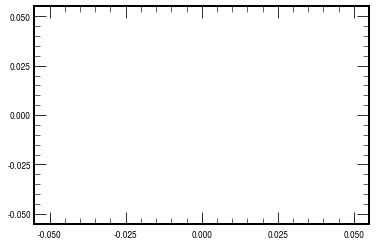

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

In [32]:
xrd_path = (
    "root://cmseos.fnal.gov//store/group/lpcsuep/Muon_counting_search/Central_NANO_2016"
)
qcd = "QCD_Pt-1000_MuEnrichedPt5_TuneCP5_13TeV-pythia8/BDCCC62F-0B9F-344F-A9E1-94D1D7097400.root"
data = "DoubleMuon_Run2018B-UL2018_MiniAODv2_GT36-v1_MINIAOD/9E3597A5-E6D1-5C4C-8952-AD72A0D11C10.root"

file = nanoevents.NanoEventsFactory.from_root(
    os.path.join(xrd_path, qcd), schemaclass=nanoevents.NanoAODSchema
)

events = file.events()

In [9]:
def muon_filter(events):
    muons = events.Muon
    events, muons = events[ak.num(muons) > 0], muons[ak.num(muons) > 0]
    clean_muons = (muons.mediumId) & (abs(muons.eta) < 2.4) & (abs(muons.dz) < 0.1)
    muons = muons[clean_muons]
    select_by_muons_low = ak.num(muons, axis=-1) > 2
    events = events[select_by_muons_low]
    muons = muons[select_by_muons_low]

    # Since the 3rd muon pt cut varies, need to apply it also to the leading and subleading muons
    pt_cuts = (muons[:, 0].pt > 17) & (muons[:, 1].pt > 8)
    return events[pt_cuts], muons[pt_cuts]

In [10]:
def mass_cut(events, muons, mass_min=3.8, dz_min=np.inf, n_pairs=3):
    dimuons = ak.combinations(muons, 2, fields=["mu1", "mu2"])
    dimuon_masses = (dimuons.mu1 + dimuons.mu2).mass
    dimuon_dz = abs(dimuons.mu1.dz - dimuons.mu2.dz)
    dimuon_masses = dimuon_masses[dimuon_dz < dz_min]
    pass_mass_cut = ak.sum(dimuon_masses > mass_min, axis=-1) >= n_pairs
    # pass_mass_cut = (
    #     ((muons[:, 0] + muons[:, 1]).mass > mass_min)
    #     & ((muons[:, 0] + muons[:, 2]).mass > mass_min)
    #     & ((muons[:, 1] + muons[:, 2]).mass > mass_min)
    # )
    # pass_dz_cut = (
    #     (abs(muons[:, 0].dz - muons[:, 1].dz) < dz_min)
    #     & (abs(muons[:, 0].dz - muons[:, 2].dz) < dz_min)
    #     & (abs(muons[:, 1].dz - muons[:, 2].dz) < dz_min)
    # )
    events = events[pass_mass_cut]
    muons = muons[pass_mass_cut]
    return events, muons

In [18]:
events.TrigObj.filterBits

<Array [[294, 292, 292, 292, ... 144, 3, 135]] type='676440 * var * int32[parame...'>

In [38]:
ak.sum(
    ak.num(
        events.TrigObj[
            (events.TrigObj.id == 13)
            & ak.values_astype(
                # ((events.TrigObj.filterBits >> 0) & 1),  # flag for TrkIsoVVL
                ((events.TrigObj.filterBits >> 4) & 1),  # flag for 2mu
                np.bool8,
            )
        ]
    )
)

0

In [30]:
events = events[events.HLT.Mu17_TrkIsoVVL_Mu8_TrkIsoVVL_DZ]
events, muons = muon_filter(events)
print("nEvents:", len(muons))
print("muons:", muons)

# events, muons = mass_cut(events, muons, mass_min=3.8, dz_min=0.1, n_pairs=3)
# print("nEvents:", len(muons))
# print("muons:", muons)

trig_muons = events.TrigObj[
    (events.TrigObj.id == 13)
    & ak.values_astype(
        ((events.TrigObj.filterBits >> 0) & 1)  # flag for TrkIsoVVL
        & ((events.TrigObj.filterBits >> 4) & 1),  # flag for 2mu
        np.bool8,
    )
]
print("trig_muons:", trig_muons)
mu_idx = ak.local_index(muons, axis=1)
trig_idx = ak.local_index(trig_muons, axis=1)

pairs = ak.cartesian({"mu": muons, "trig": trig_muons}, axis=1, nested=True)
print("pairs:", pairs)
pairs_idx = ak.cartesian(
    {
        "mu_idx": mu_idx,
        "trig_idx": trig_idx,
    },
    axis=1,
    nested=True,
)
pair0, pair1 = ak.unzip(pairs)  # type: ignore[index]
pair0_idx, pair1_idx = ak.unzip(pairs_idx)  # type: ignore[index]
matched = ak.any(
    (pair0.delta_r(pair1) < 0.01) & (abs(pair0.pt - pair1.pt) / pair1.pt < 0.1), axis=-1
)
print("matched:", matched)

# Form all combinations
mu1, mu2, mu3 = ak.unzip(ak.combinations(muons, 3, axis=1))
mu1_idx, mu2_idx, mu3_idx = ak.unzip(ak.argcombinations(muons, 3, axis=1))
print("mu1.pt:", mu1.pt)
print("mu2.pt:", mu2.pt)
print("mu3.pt:", mu3.pt)
print("mu1_idx:", mu1_idx)
print("mu2_idx:", mu2_idx)
print("mu3_idx:", mu3_idx)

nEvents: 128

muons: [[Muon, Muon, Muon], [Muon, Muon, Muon], ... [Muon, Muon, Muon], [Muon, Muon, Muon]]

trig_muons: [[], [], [], [], [], [], [], [], [], [], ... [], [], [], [], [], [], [], [], [], []]

pairs: [[[], [], []], [[], [], []], [[], [], [], ... [], []], [[], [], []], [[], [], []]]

matched: [[False, False, False], [False, False, ... False, False], [False, False, False]]

...

mu2.pt: [[53.9], [23.4], [11.4], [77.9], [24.2], ... [12.6], [32.6], [49], [55.1], [30]]

mu3.pt: [[14.1], [14], [4.24], [10.3], [4.89], ... [3.87], [22.5], [11.1], [6.44], [9.52]]

mu1_idx: [[0], [0], [0], [0], [0], [0], [0], [0, ... [0, 0, 0, 1], [0], [0], [0], [0], [0]]

mu2_idx: [[1], [1], [1], [1], [1], [1], [1], [1, ... [1, 1, 2, 2], [1], [1], [1], [1], [1]]

mu3_idx: [[2], [2], [2], [2], [2], [2], [2], [2, ... [2, 3, 3, 3], [2], [2], [2], [2], [2]]

In [23]:
# Form a array that indicates whether the muons in the triplets have matched to a trigger object
print("nMatched:", len(matched))
mu1_is_matching = matched[mu1_idx]
mu2_is_matching = matched[mu2_idx]
mu3_is_matching = matched[mu3_idx]
print("mu1_is_matching:", mu1_is_matching)
print("mu2_is_matching:", mu2_is_matching)
print("mu3_is_matching:", mu3_is_matching)

nMatched: 49

mu1_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu2_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu3_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

In [24]:
# Muon is probe if other two are tags
mu1_probes = mu1[mu2_is_matching & mu3_is_matching]
mu2_probes = mu2[mu1_is_matching & mu3_is_matching]
mu3_probes = mu3[mu1_is_matching & mu2_is_matching]
print("nMu1_probes:", len(mu1_probes))
print("mu1.pt:", mu1.pt)
print("mu2.pt:", mu2.pt)
print("mu3.pt:", mu3.pt)
print("mu1_is_matching:", mu1_is_matching)
print("mu2_is_matching:", mu2_is_matching)
print("mu3_is_matching:", mu3_is_matching)
print("mu1_probes.pt:", mu1_probes.pt)
print("mu2_probes.pt:", mu2_probes.pt)
print("mu3_probes.pt:", mu3_probes.pt)

nMu1_probes: 49

mu1.pt: [[65.3], [32.4], [19.2], [32.4], ... 132, 34.9], [21.9, 21.9, 21.9, 13.5], [57]]

mu2.pt: [[53.9], [23.4], [11.4], [16.4], ... 27.4, 27.4], [13.5, 13.5, 12.5, 12.5], [12.6]]

mu3.pt: [[14.1], [14], [4.24], [11], [6.55, ... 26.5, 26.5, 26.5], [12.5, 5, 5, 5], [3.87]]

mu1_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu2_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu3_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu1_probes.pt: [[], [], [], [], [], [], [], [], [], [], ... [], [], [], [], [], [], [], [], [], []]

mu2_probes.pt: [[], [], [], [], [], [], [], [], [], [], ... [], [], [], [], [], [], [], [], [], []]

mu3_probes.pt: [[], [], [], [], [], [], [], [], [], [], ... [], [], [], [], [], [], [], [], [], []]

In [25]:
mu_probes = ak.concatenate([mu1_probes, mu2_probes, mu3_probes], axis=-1)
print("muons.pt", muons.pt)
print("mu1_is_matching:", mu1_is_matching)
print("mu2_is_matching:", mu2_is_matching)
print("mu3_is_matching:", mu3_is_matching)
print("mu_probes.pt", mu_probes.pt)

muons.pt [[65.3, 53.9, 14.1], [32.4, 23.4, 14], ... 21.9, 13.5, 12.5, 5], [57, 12.6, 3.87]]

mu1_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu2_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu3_is_matching: [[False], [False], [False], [False, ... [False, False, False, False], [False]]

mu_probes.pt [[], [], [], [], [], [], [], [], [], [], ... [], [], [], [], [], [], [], [], [], []]

In [26]:
at_least_one_probe = ak.num(mu_probes) > 0
events = events[at_least_one_probe]
muons = muons[at_least_one_probe]
mu1 = mu1[at_least_one_probe]
mu2 = mu2[at_least_one_probe]
mu3 = mu3[at_least_one_probe]
mu_probes = mu_probes[at_least_one_probe]

In [28]:
print(
    (muons[~events.HLT.TripleMu_5_3_3, 0] + muons[~events.HLT.TripleMu_5_3_3, 1]).mass
)
print(
    (muons[~events.HLT.TripleMu_5_3_3, 0] + muons[~events.HLT.TripleMu_5_3_3, 2]).mass
)
print(
    (muons[~events.HLT.TripleMu_5_3_3, 1] + muons[~events.HLT.TripleMu_5_3_3, 2]).mass
)

[]

[]

[]

In [16]:
print(mu_probes.pt)

[[15.8], [17.4, 13.5], [27, 25, 10.6, 4.02, ... 74.7, 19], [13.2], [16.3], [10.6]]

In [17]:
ak.sum(events.HLT.TripleMu_5_3_3_Mass3p8_DZ) / len(events.HLT.TripleMu_5_3_3_Mass3p8_DZ)

0.8991228070175439

In [104]:
print(
    ak.zip(
        [
            events.luminosityBlock,
            events.event,
            events.HLT.TripleMu_5_3_3_Mass3p8_DZ,
            mu_probes.pt,
        ]
    )
)

[[(9973, 79108083, True, 39.2)], [(9973, ... [(23398, 185614207, True, 134)]]

In [105]:
print(events.luminosityBlock[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ].to_numpy())

[13930 13930 43695 13774 39724 17439 17373 36462 30935 22447 21899 36808
 22229]

In [104]:
filenames = [
    "3ED57C5B-E745-FB4F-A300-8B3121EC0EE4.root",
    "AEA82761-074A-0C4B-81CC-4EE508E1CE7F.root",
    "7B252BF0-3839-F04C-9F43-4F3AB7A8998E.root",
    "B1B62316-816F-4240-91AE-C5ED9EAB6B80.root",
    "AC88041C-F481-8940-800D-CD65C5A97A37.root",
    "46FC3B03-0071-6A4A-B988-0E4C873AD388.root",
    "46FC3B03-0071-6A4A-B988-0E4C873AD388.root",
    "0CAA1F7A-D3BE-C740-A19B-E80879E3B339.root",
    "DE0D795C-178E-4C48-9080-0958B1729FCB.root",
    "DE0D795C-178E-4C48-9080-0958B1729FCB.root",
    "33EDE27A-D6DD-8445-A9ED-B02296522533.root",
    "33EDE27A-D6DD-8445-A9ED-B02296522533.root",
    "5A869657-8272-F141-A897-AC6E051D52C3.root",
    "5A869657-8272-F141-A897-AC6E051D52C3.root",
    "86F8DE15-5323-6147-9789-E47D210F767C.root",
    "FEE2FACF-DACD-FE49-BFCE-97E8F04AD569.root",
    "FEE2FACF-DACD-FE49-BFCE-97E8F04AD569.root",
]

In [105]:
print(
    ak.zip(
        [
            # events.luminosityBlock[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            # events.event[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            # filenames,
            events.HLT.TripleMu_5_3_3_Mass3p8_DZ[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            events.HLT.TripleMu_10_5_5_DZ[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            events.HLT.TripleMu_12_10_5[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            muons.pt[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 0],
            muons.pt[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 1],
            muons.pt[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 2],
            muons.eta[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 0],
            muons.eta[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 1],
            muons.eta[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 2],
            muons.dz[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 0],
            muons.dz[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 1],
            muons.dz[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ, 2],
            (muons[:, 0] + muons[:, 1]).mass[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            (muons[:, 0] + muons[:, 2]).mass[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            (muons[:, 1] + muons[:, 2]).mass[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ],
            # mu_probes.pt[~events.HLT.TripleMu_5_3_3_Mass3p8_DZ]
        ]
    ).to_numpy()
)

[(False,  True,  True, 116.18,  89.94, 86.81, -0.46, -0.46, -0.69,  0.  ,  7.62e-04, -0.01,   1.43, 202.12, 177.86)
 (False,  True,  True,  17.43,  11.13, 10.76, -1.12, -0.68,  0.54, -0.03,  2.64e-02,  0.07,  23.47,  27.61,  25.65)
 (False,  True,  True, 474.38,  80.73, 60.5 ,  0.49,  0.48,  0.76, -0.01,  3.35e-02, -0.09,   1.55, 149.43,  61.71)
 (False, False, False,  25.97,  14.56,  4.6 ,  1.92,  2.03, -0.76,  0.01,  7.59e-03,  0.  ,   6.17,  39.19,  30.99)
 (False, False, False,  44.68,  10.39,  3.84, -0.81, -1.43, -1.62,  0.  ,  3.59e-03,  0.08,  14.3 ,  12.11,   3.84)
 (False,  True,  True, 122.66,  34.34, 27.33,  0.18, -0.91, -0.89,  0.  ,  1.91e-03,  0.01,  89.93,  78.72,   0.88)
 (False, False, False, 372.72,  15.89,  4.71, -0.67, -0.54, -0.68,  0.01, -2.19e-02, -0.  , 106.44,  83.76,  13.03)
 (False, False, False,  45.01,  18.17,  9.3 , -0.88,  0.12, -0.63, -0.  ,  9.91e-03, -0.01,  56.31,  38.91,  11.63)
 (False,  True,  True,  49.17,  14.38, 13.17, -0.15,  1.55,  1.63, -0.  ,  1.42e-02, -0.09,  67.  ,  66.01,   1.13)
 (False,  True,  True, 256.91,  17.04,  5.73, -0.45, -0.51, -0.59, -0.  , -9.07e-03,  0.  , 114.3 ,  66.55,   0.76)
 (False, False, False,  92.72,  44.41,  5.02,  1.27,  1.27,  1.96, -0.02, -3.20e-02,  0.01,  14.67,  19.67,  11.83)
 (False, False, False,  54.24,  17.08,  6.22,  1.85,  1.69, -1.6 , -0.  , -2.42e-03, -0.  ,   4.76, 104.58,  54.44)
 (False, False, False,  57.74,  39.  ,  3.31,  2.18,  2.06, -0.24, -0.02,  9.47e-04, -0.01,   7.03,  44.42,  33.85)
 (False, False, False, 427.03, 134.87, 23.24, -0.42, -0.33, -0.42,  0.02,  2.47e-02, -0.03, 457.45, 151.07,  95.6 )
 (False, False, False, 308.33,  10.21,  3.24,  0.72,  0.31,  0.91,  0.01, -4.13e-03, -0.  ,  31.16,  12.31,   5.33)
 (False, False, False, 350.16,  61.5 ,  4.41,  0.16, -1.83, -0.57, -0.  , -3.84e-03, -0.  , 445.28,  83.71,  22.74)
 (False, False, False,  93.14,  43.37,  9.54, -0.66,  1.47, -0.25,  0.01, -2.06e-03, -0.04, 191.62,  47.95,  55.69)
 (False, False, False, 148.24,  55.03,  4.2 , -0.16, -1.21, -1.91, -0.  ,  3.05e-03,  0.02,  99.7 ,  60.68,  22.49)
 (False, False, False,  24.07,   8.44,  4.82,  0.98, -1.03, -1.17,  0.01,  4.90e-02,  0.08,  39.74,  30.02,   3.83)
 (False, False, False,  60.9 ,  46.5 ,  8.33,  0.76,  2.16,  2.4 ,  0.  ,  3.37e-05,  0.04, 108.4 ,  53.31,   6.27)
 (False,  True,  True,  99.55,  37.64, 17.8 , -0.1 , -0.1 ,  0.08, -0.01,  4.59e-03, -0.01,   1.38,  41.27,  25.87)
 (False,  True,  True, 129.62,  91.78, 42.72, -0.31, -0.31, -0.34, -0.01, -1.89e-02,  0.  ,   0.5 , 136.81, 115.04)
 (False, False, False,  55.71,  26.28,  9.59, -1.08,  0.35,  0.45, -0.04, -7.15e-04, -0.  ,  91.78,  39.43,  26.9 )
 (False,  True,  True, 293.69,  12.04,  6.68, -0.55, -0.68, -0.47, -0.01,  4.82e-04, -0.03,  25.7 ,   4.71,   4.69)
 (False,  True,  True, 310.66, 114.26, 11.71, -0.49, -0.49,  0.58,  0.  ,  4.36e-03, -0.  ,   0.87, 136.87,  83.04)
 (False,  True,  True,  59.53,  37.45,  9.71,  0.17,  0.16,  0.12, -0.01, -3.89e-02,  0.05,   0.57,  47.78,  
37.89)]

In [58]:
import ROOT

In [96]:
mu_probes_pt = ak.flatten(mu_probes.pt).to_numpy()
mu_probes_ = mu_probes[events.HLT.TripleMu_5_3_3_Mass3p8_DZ]
mu_probes_pt_ = ak.flatten(mu_probes_.pt).to_numpy()

h_DEN = ROOT.TH1F("h_DEN", "h_DEN", 40, 0, 20)
h_NUM = ROOT.TH1F("h_NUM", "h_NUM", 40, 0, 20)
h_DEN.FillN(
    mu_probes_pt.size,
    np.asarray(mu_probes_pt, dtype=np.float64),
    10 * np.ones(mu_probes_pt.size),
)
h_NUM.FillN(
    mu_probes_pt_.size,
    np.asarray(mu_probes_pt_, dtype=np.float64),
    10 * np.ones(mu_probes_pt_.size),
)

Warning in <TROOT::Append>: Replacing existing TH1: h_DEN (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_NUM (Potential memory leak).


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


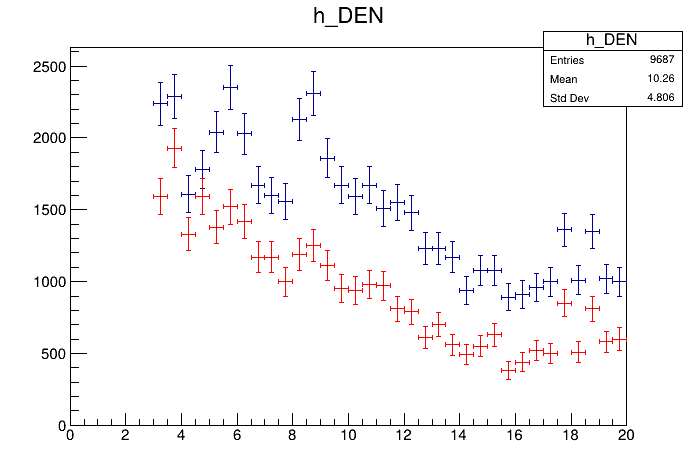

In [97]:
c = ROOT.TCanvas("c")
h_DEN.Draw("E1")
h_NUM.Draw("E1 SAME")
h_NUM.SetLineColor(ROOT.kRed)
c.Draw()

In [98]:
h_eff = ROOT.TEfficiency(h_NUM, h_DEN)

Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TEfficiency::GetEfficiencyErrorLow>: frequentist confidence intervals for weights are only supported by the normal approximation
Info in <TEfficiency::GetEfficiencyErrorLow>: setting statistic option to kFNormal


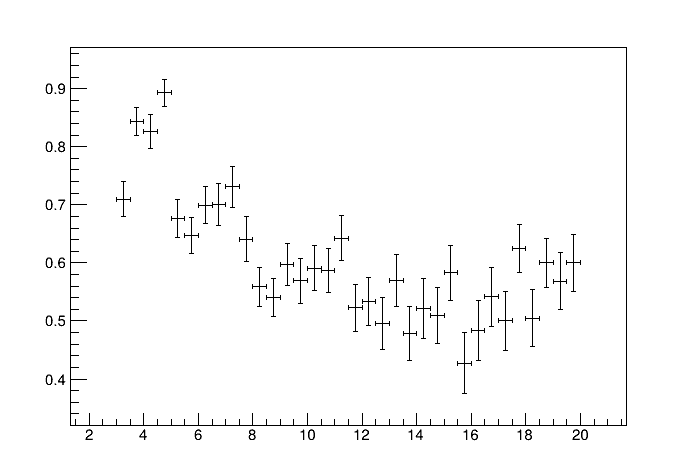

In [99]:
c = ROOT.TCanvas("c")
h_eff.Draw()
c.Draw()

In [101]:
import hist

In [108]:
hist_NUM = hist.Hist.new.Reg(40, 0, 20).Weight()
hist_DEN = hist.Hist.new.Reg(40, 0, 20).Weight()

In [109]:
hist_NUM.fill(mu_probes_pt_, weight=10 * np.ones(mu_probes_pt_.size))
hist_DEN.fill(mu_probes_pt, weight=10 * np.ones(mu_probes_pt.size))

Hist(Regular(40, 0, 20, label='Axis 0'), storage=Weight()) # Sum: WeightedSum(value=51170, variance=511700) (WeightedSum(value=96870, variance=968700) with flow)

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7efd5cf83f50>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

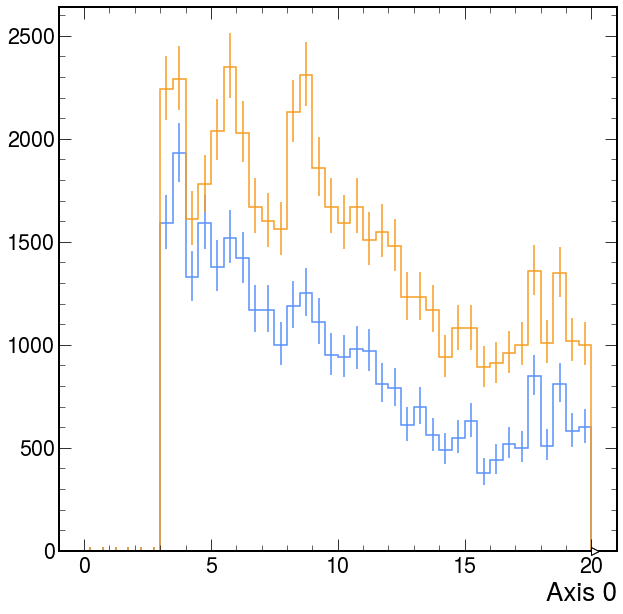

In [110]:
hist_NUM.plot()
hist_DEN.plot()

In [112]:
h_NUM_conv = uproot.to_writable(hist_NUM).to_pyroot()
h_DEN_conv = uproot.to_writable(hist_DEN).to_pyroot()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


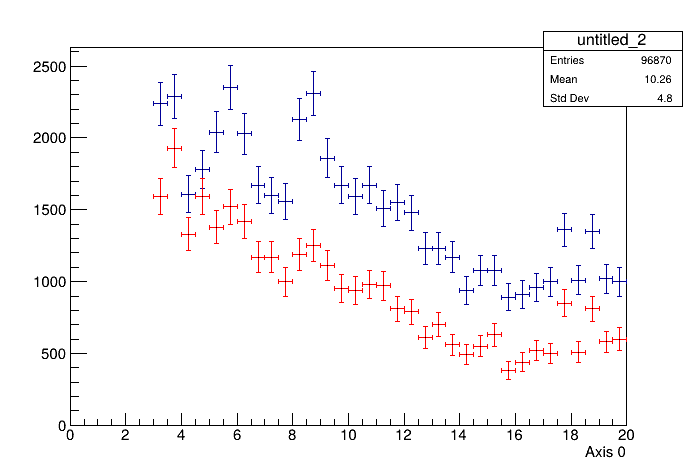

In [113]:
c = ROOT.TCanvas("c")
h_DEN_conv.Draw("E1")
h_NUM_conv.Draw("E1 SAME")
h_NUM_conv.SetLineColor(ROOT.kRed)
c.Draw()

In [136]:
h_eff = ROOT.TEfficiency(h_NUM_conv, h_DEN_conv)

Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TEfficiency::GetEfficiencyErrorLow>: frequentist confidence intervals for weights are only supported by the normal approximation
Info in <TEfficiency::GetEfficiencyErrorLow>: setting statistic option to kFNormal


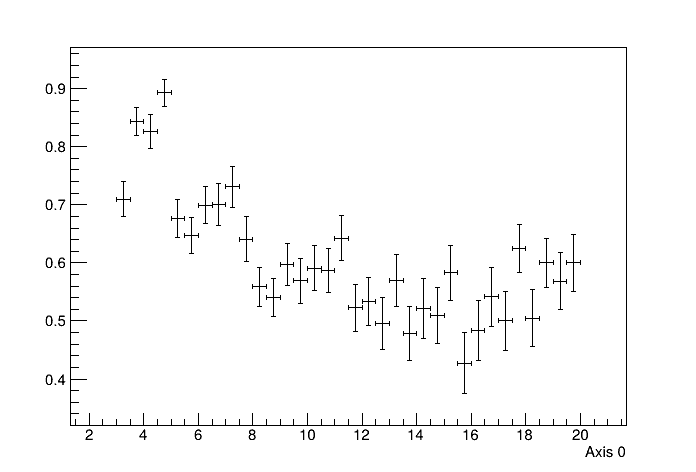

In [137]:
c = ROOT.TCanvas("c")
h_eff.Draw()
c.Draw()

In [118]:
h_NUM.GetBinError(10)

126.09520212918491

In [119]:
h_NUM_conv.GetBinError(10)

126.09520212918491

In [120]:
h_NUM.GetBinContent(10)

1590.0

In [121]:
h_NUM_conv.GetBinContent(10)

1590.0

In [122]:
h_NUM.Print()

TH1.Print Name  = h_NUM, Entries= 5628, Total sum= 31820


In [123]:
h_NUM_conv.Print()

TH1.Print Name  = untitled_1, Entries= 56280, Total sum= 31820


In [126]:
h_NUM_conv.GetEffectiveEntries()

31820.0

In [127]:
h_NUM.GetEffectiveEntries()

3182.0

In [134]:
for i in range(1, h_DEN.GetNbinsX() + 1):
    print(i, h_DEN.GetBinContent(i), h_DEN.GetBinError(i), h_DEN.GetEffectiveEntries())

1 0.0 0.0 5117.0

2 0.0 0.0 5117.0

3 0.0 0.0 5117.0

4 0.0 0.0 5117.0

5 0.0 0.0 5117.0

...

36 1360.0 116.61903789690601 5117.0

37 1010.0 100.4987562112089 5117.0

38 1350.0 116.1895003862225 5117.0

39 1020.0 100.99504938362078 5117.0

40 1000.0 100.0 5117.0

In [135]:
for i in range(1, h_DEN_conv.GetNbinsX() + 1):
    print(
        i,
        h_DEN_conv.GetBinContent(i),
        h_DEN_conv.GetBinError(i),
        h_DEN_conv.GetEffectiveEntries(),
    )

1 0.0 0.0 5117.0

2 0.0 0.0 5117.0

3 0.0 0.0 5117.0

4 0.0 0.0 5117.0

5 0.0 0.0 5117.0

...

36 1360.0 116.61903789690601 5117.0

37 1010.0 100.4987562112089 5117.0

38 1350.0 116.1895003862225 5117.0

39 1020.0 100.99504938362078 5117.0

40 1000.0 100.0 5117.0

In [132]:
h_DEN.Sumw2()
h_DEN.Rebuild()
h_DEN.ResetStats()
h_DEN.ComputeIntegral()

1.0

Warning in <TH1F::Sumw2>: Sum of squares of weights structure already created


In [133]:
h_DEN_conv.Sumw2()
h_DEN_conv.Rebuild()
h_DEN_conv.ResetStats()
h_DEN_conv.ComputeIntegral()

1.0

Warning in <TH1D::Sumw2>: Sum of squares of weights structure already created


In [141]:
h_eff.GetEfficiencyErrorLow(10)

0.02314436976453557